In [26]:
import numpy as np
import pandas as pd
import yfinance as yf

downloading 5 year data


In [27]:
btc = yf.download("BTC-USD", start = "2021-01-01", end = "2026-01-01")

[*********************100%***********************]  1 of 1 completed


In [28]:
eth = yf.download("ETH-USD", start = "2021-01-01", end = "2026-01-01")

[*********************100%***********************]  1 of 1 completed


In [29]:
df = btc.copy()
print(df.shape)

print(df.columns)



(1826, 5)
MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])


cleaning


In [31]:
def rolling_zscore(df : pd.DataFrame, window_size:int, threshold:float):

    work = df.copy()

    returns = work["Close"].pct_change()

    # tradeoff that we get nan for first 14 entries
    mean = returns.rolling(window=window_size).mean().replace(0, np.nan)
    std =  returns.rolling(window=window_size).std().replace(0, np.nan)


    # normalizing 

    work['rolling_z_score'] = (returns - mean)/std

    # filter

    outlier = work[work['rolling_z_score'].abs() > threshold]

    return work, outlier
    

In [36]:
eth.index.duplicated().sum()

np.int64(0)

In [43]:
btc[(btc['High'] < btc['Low']) |
                    (btc["Close"] > btc["High"]) |
                    (btc["Close"] < btc["Low"])]

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2021-01-01,NaN,NaN,NaN,NaN,NaN
2021-01-02,NaN,NaN,NaN,NaN,NaN
2021-01-03,NaN,NaN,NaN,NaN,NaN
2021-01-04,NaN,NaN,NaN,NaN,NaN
2021-01-05,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2025-12-27,NaN,NaN,NaN,NaN,NaN
2025-12-28,NaN,NaN,NaN,NaN,NaN


In [44]:
def cleaner(df:pd.DataFrame, filter_threshold:float, filter_window_size : int):

    work = df.copy()

    # flaten from multiindex col

    work.columns = df.columns.get_level_values(0)

    #sorting
    work = work.sort_index()

    # checking 0 vol bars adn counting them
    zero_vol = work['Volume'] == 0
    zero_cnt = zero_vol.sum()


    # filtering

    work, outlier = rolling_zscore(work, window_size=filter_window_size, threshold=filter_threshold)


    # absolutely invalid things (high < low ) (closed above high) (closed below low)


    invalids = work[(work['High'] < work['Low']) |
                    (work["Close"] > work["High"]) |
                    (work["Close"] < work["Low"])]


    print('\n\n')

    print("zero vol entries :  " , zero_cnt)

    print("rolling zscore normalising outliers  : " , len(outlier), " window : ", filter_window_size, "d ,  threshold : ", filter_threshold , "sigma")
        
    print("absolutely invalid entries : " , len(invalids))
    print('\n\n')
    print("$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$")


    return work, {"outliers  " : outlier , "invalids " : invalids}


In [48]:
btc_clean , btc_waste = cleaner(btc, 3.5, 14)
eth_clean , eth_waste = cleaner(eth, 3.5, 14)




zero vol entries :   0
rolling zscore normalising outliers  :  0  window :  14 d ,  threshold :  3.5 sigma
absolutely invalid entries :  0



$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$



zero vol entries :   0
rolling zscore normalising outliers  :  0  window :  14 d ,  threshold :  3.5 sigma
absolutely invalid entries :  0



$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$


# plotting by gemini

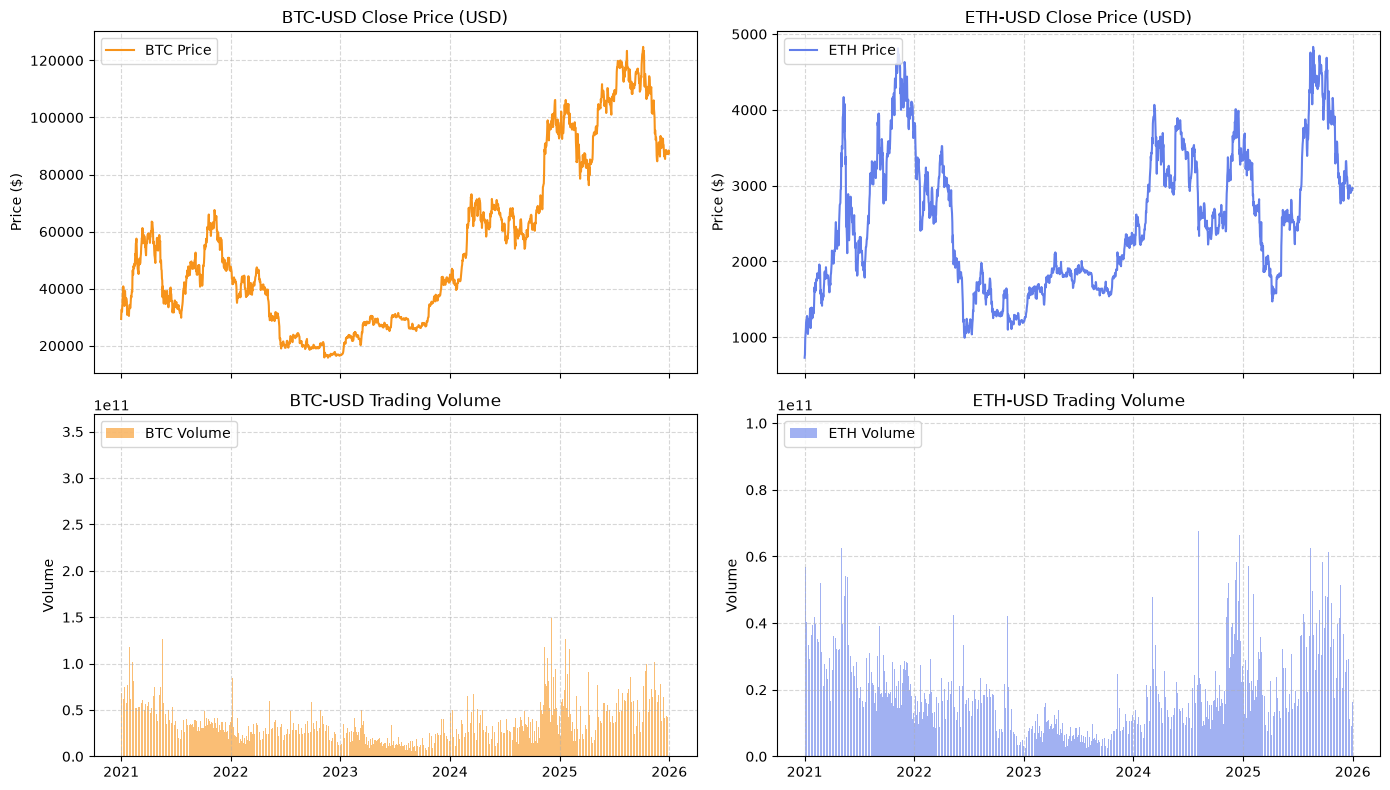

In [30]:
import matplotlib.pyplot as plt

# Create 2x2 figure grid
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# 1. BTC Price
axes[0, 0].plot(btc_clean.index, btc_clean['Close'], color='#F7931A', linewidth=1.5, label='BTC Price')
axes[0, 0].set_title('BTC-USD Close Price (USD)')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)
axes[0, 0].legend(loc='upper left')

# 2. ETH Price
axes[0, 1].plot(eth_clean.index, eth_clean['Close'], color='#627EEA', linewidth=1.5, label='ETH Price')
axes[0, 1].set_title('ETH-USD Close Price (USD)')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)
axes[0, 1].legend(loc='upper left')

# 3. BTC Volume
axes[1, 0].bar(btc_clean.index, btc_clean['Volume'], color='#F7931A', alpha=0.6, label='BTC Volume')
axes[1, 0].set_title('BTC-USD Trading Volume')
axes[1, 0].set_ylabel('Volume')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)
axes[1, 0].legend(loc='upper left')

# 4. ETH Volume
axes[1, 1].bar(eth_clean.index, eth_clean['Volume'], color='#627EEA', alpha=0.6, label='ETH Volume')
axes[1, 1].set_title('ETH-USD Trading Volume')
axes[1, 1].set_ylabel('Volume')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)
axes[1, 1].legend(loc='upper left')

plt.tight_layout()
plt.show()

showing the important periods 

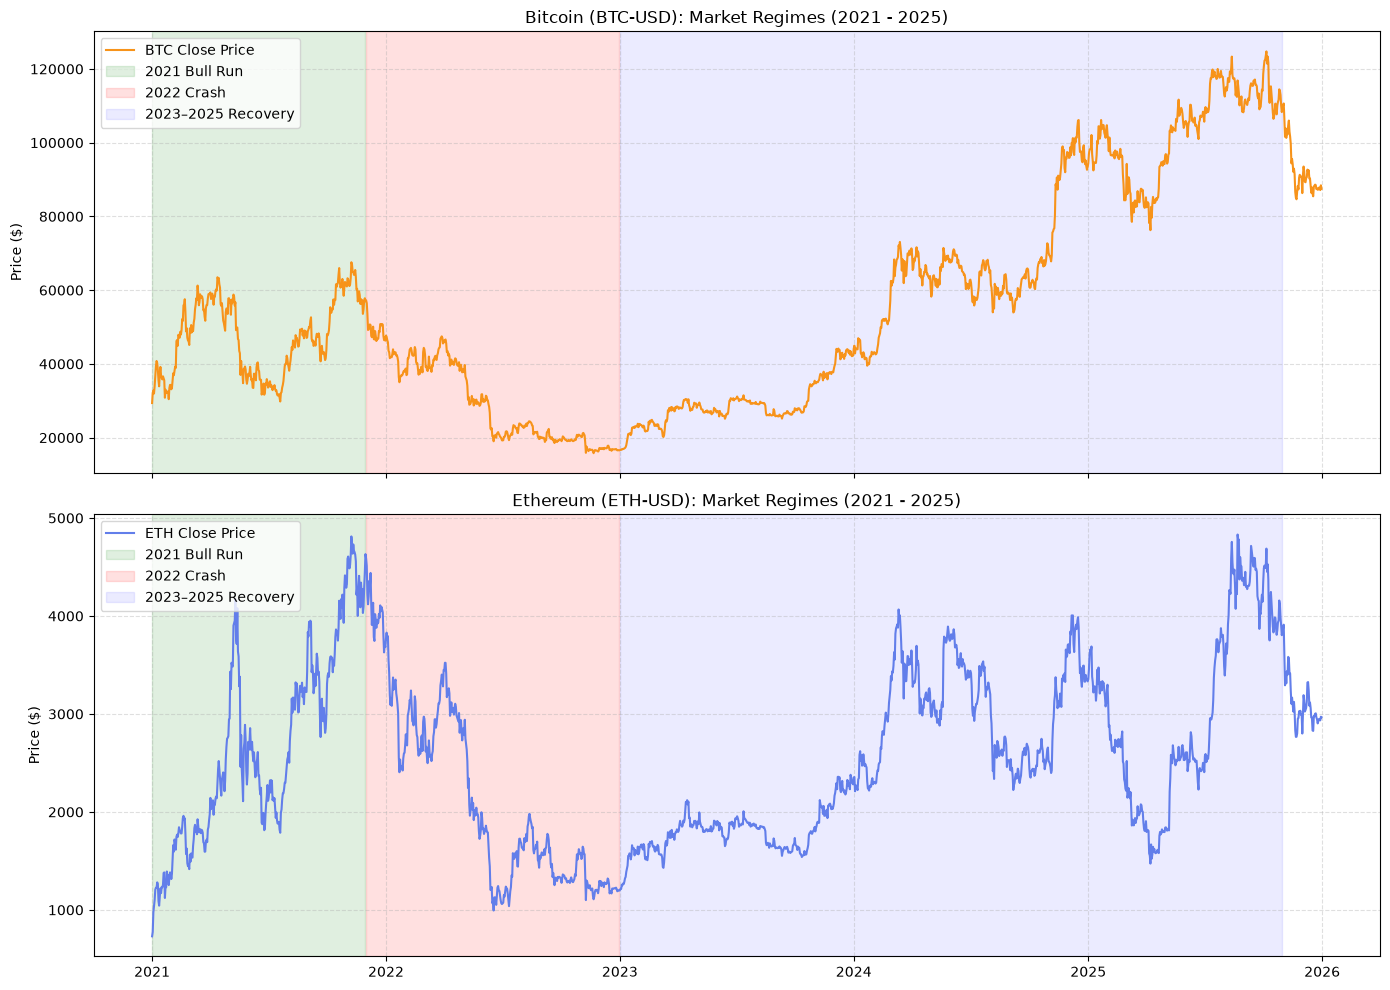

In [31]:
import matplotlib.pyplot as plt

# Define market regime date ranges
regimes = [
    {"label": "2021 Bull Run", "start": "2021-01-01", "end": "2021-11-30", "color": "green", "alpha": 0.12},
    {"label": "2022 Crash", "start": "2021-12-01", "end": "2022-12-31", "color": "red", "alpha": 0.12},
    {"label": "2023–2025 Recovery", "start": "2023-01-01", "end": "2025-10-31", "color": "blue", "alpha": 0.08}
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Plot BTC Price & Volume ---
ax1.plot(btc_clean.index, btc_clean['Close'], color='#F7931A', linewidth=1.5, label='BTC Close Price')
ax1.set_title('Bitcoin (BTC-USD): Market Regimes (2021 - 2025)')
ax1.set_ylabel('Price ($)')
ax1.grid(True, linestyle='--', alpha=0.4)

# --- Plot ETH Price & Volume ---
ax2.plot(eth_clean.index, eth_clean['Close'], color='#627EEA', linewidth=1.5, label='ETH Close Price')
ax2.set_title('Ethereum (ETH-USD): Market Regimes (2021 - 2025)')
ax2.set_ylabel('Price ($)')
ax2.grid(True, linestyle='--', alpha=0.4)

# --- Add Shaded Regimes to both subplots ---
for ax in [ax1, ax2]:
    for regime in regimes:
        ax.axvspan(
            xmin=pd.to_datetime(regime['start']), 
            xmax=pd.to_datetime(regime['end']), 
            color=regime['color'], 
            alpha=regime['alpha'], 
            label=regime['label']
        )

# Remove duplicate labels in legend
handles1, labels1 = ax1.get_legend_handles_labels()
by_label1 = dict(zip(labels1, handles1))
ax1.legend(by_label1.values(), by_label1.keys(), loc='upper left')

handles2, labels2 = ax2.get_legend_handles_labels()
by_label2 = dict(zip(labels2, handles2))
ax2.legend(by_label2.values(), by_label2.keys(), loc='upper left')

plt.tight_layout()
plt.show()

benchmark formation

In [55]:
def benchmark(df : pd.DataFrame, risk_free_return : float):

    work = df.copy()

    closing_price = work['Close']

    # daily return
    returns = closing_price.pct_change().dropna()

    # buy hold total return 
    p_start = closing_price.iloc[0]

    p_end = closing_price.iloc[-1]

    buy_hold_return = (p_end-p_start)/p_start


    # max drawdown part :
    
    cur_max = closing_price.cummax()
    drawdown = (closing_price - cur_max) / cur_max

    max_drawdown = drawdown.min()

    max_drawdown_index = drawdown.idxmin() # date


    # sharpe ratio :

    year = 365
    # for precision , compound interest formula is used for calculating daily rfr
    daily_riskfree = (1+risk_free_return)**(1/year) - 1
    
    diff = returns - daily_riskfree


    if diff.std() != 0: 
        sharpe = (diff.mean() / diff.std()) * (np.sqrt(year)) 
    else:
        sharpe = np.nan



    print()
    print("benchmark \n")
    print("total returns (buy and hold) : " , buy_hold_return)
    print("max drawdown : ", max_drawdown , " trough at :", max_drawdown_index )
    print("sharpe  : ", sharpe)
    print()
    print("#######################################")

    return {
        'total return' : buy_hold_return,
        'max drawdown' : max_drawdown,
        'sharpe' : sharpe
    }


In [34]:
btc_bench = benchmark(btc_clean, risk_free_return=0.04)


benchmark 

total returns (buy and hold) :  1.979109902506495
max drawdown :  -0.7663456370856908  trough at : 2022-11-21 00:00:00+00:00
sharpe  :  0.5983311061166807

#######################################


total range


In [35]:
import numpy as np
import pandas as pd

In [46]:
def total_r(df : pd.DataFrame, period : int = 14):

    work = df.copy()

    high = work['High']
    low = work['Low']
    close = work['Close']


    n1 = high-low
    n2 = np.abs(high-close.shift(1))
    n3 = np.abs(low - close.shift(1))


    tr = np.maximum(n1, np.maximum(n2, n3))

    return tr


In [49]:
btc_tr = total_r(btc_clean)
eth_tr = total_r(eth_clean)

In [57]:
btc_tr.iloc[1]

np.float64(4063.935546875)

In [89]:
def wilder_smoothen(series : pd.Series, period : int = 14):

    temp = pd.Series(np.nan, index=df.index)
    
    # for first period , its just mean of values
    temp.iloc[period-1] = series.iloc[:period].mean()

    for i in range(period, len(series)):
        temp.iloc[i] = ((temp.iloc[i-1] * (period-1) ) + series.iloc[i]) / period

    return temp

In [83]:
btc_clean.Close

2021-01-01 00:00:00+00:00    29374.152344
2021-01-02 00:00:00+00:00    32127.267578
2021-01-03 00:00:00+00:00    32782.023438
2021-01-04 00:00:00+00:00    31971.914062
2021-01-05 00:00:00+00:00    33992.429688
                                 ...     
2025-12-27 00:00:00+00:00    87802.156250
2025-12-28 00:00:00+00:00    87835.835938
2025-12-29 00:00:00+00:00    87138.140625
2025-12-30 00:00:00+00:00    88430.132812
2025-12-31 00:00:00+00:00    87508.828125
Freq: D, Name: Close, Length: 1826, dtype: float64

In [ ]:
def atr(tr : pd.Series, period : int = 14):

    aatr = wilder_smoothen(tr, n_fac=period)

    return aatr

In [80]:
btc_atr = atr(btc_clean, btc_tr)
eth_atr = atr(eth_clean, eth_tr)

In [104]:
def dx(df : pd.DataFrame, atr : pd.Series , period : int = 14):

    df.index = df.index.tz_localize(None)   
    
    atr.index = atr.index.tz_localize(None)
       
    f = df['High'] - df['High'].shift(1)
    s = -df['Low'] + df['Low'].shift(1)

    
    pdm = f.where(f > 0, 0)   
    ndm = s.where(s > 0, 0)   

    spdm = wilder_smoothen(pdm, period)
    sndm = wilder_smoothen(ndm, period)

    pdi = (spdm / atr) * 100
    
    ndi = (sndm/atr) * 100

    dx = ((pdi - ndi)/(pdi + ndi)) * 100
    dx = dx.abs()
    
    return dx



In [108]:
btc_dx = dx(btc_clean, btc_atr)
avg_btc_dx = btc_dx.mean()

eth_dx = dx(eth_clean, eth_atr)
avg_eth_dx = eth_dx.mean()

